In [10]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from src.configs.defaults import *
from src.configs.train_config import TrainConfig
from src.utils.set_seed import set_seed
from src.data.utils import load_HandBonesDataset, split_train_val, encode_mask_to_rle, decode_rle_to_mask
from src.data.transforms import get_valid_transform, get_test_transform, get_tta_transform
from src.metrics.dice import dice_coef

import json
import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

In [5]:
cfg = TrainConfig(
    data_root = TRIAN_ROOT,
    saved_root = SAVED_DIR,
    saved_name="upernet_2048_flip_best.pt",
    split_file_root = "random", # SPLIT_FILE_ROOT,
        
    total=False,
    tta=True,
        
    img_size=2048,
    use_scale=True,
    use_rotate=True,
    use_flip=True,
    use_contrast=True,
        
    model_name='upernet',
    encoder_name='resnext50_32x4d',
    loss_type='BDJ',
    scheduler='warmup',
    optimizer='adam',

    batch_size=2,
    num_workers_train=NUM_WORKERS_TRAIN,
    num_workers_val=NUM_WORKERS_VAL,

    lr=LR,
    num_epochs=NUM_EPOCHS,
    val_every=VAL_EVERY,
    num_patience=NUM_PATIENCE,

    seed=RANDOM_SEED,
        
    use_wandb=False,
)

In [6]:
class XRayValidDataset(Dataset):         # valid 시각화를 위한 dataset
    def __init__(self, cfg):
        
        self.image_root = os.path.join(cfg.data_root, "DCM")
        self.label_root = os.path.join(cfg.data_root, "outputs_json")
        
        pngs, jsons = load_HandBonesDataset(self.image_root, self.label_root)
        
        filenames, labelnames = split_train_val(cfg, pngs, jsons, is_train=False)
        
        self.filenames = filenames
        self.labelnames = labelnames
        self.is_train = False
        self.transforms = get_valid_transform(cfg)
        self.tta_transforms = get_tta_transform() if cfg.tta else None
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, item):
        image_name = self.filenames[item]
        image_path = os.path.join(self.image_root, image_name)
        
        image = cv2.imread(image_path)
        image = image / 255.
        
        label_name = self.labelnames[item]
        label_path = os.path.join(self.label_root, label_name)
        
        # (H, W, NC) 모양의 label을 생성합니다.
        label_shape = tuple(image.shape[:2]) + (len(CLASSES), )
        label = np.zeros(label_shape, dtype=np.uint8)
        
        # label 파일을 읽습니다.
        with open(label_path, "r") as f:
            annotations = json.load(f)
        annotations = annotations["annotations"]
        
        # 클래스 별로 처리합니다.
        for ann in annotations:
            c = ann["label"]
            class_ind = CLASS2IND[c]
            points = np.array(ann["points"])
            
            # polygon 포맷을 dense한 mask 포맷으로 바꿉니다.
            class_label = np.zeros(image.shape[:2], dtype=np.uint8)
            cv2.fillPoly(class_label, [points], 1)
            label[..., class_ind] = class_label
        
        if self.transforms is not None:
            inputs = {"image": image, "mask": label} if self.is_train else {"image": image}
            result = self.transforms(**inputs)
            
            image = result["image"]
            label = result["mask"] if self.is_train else label
        
        if self.tta_transforms is not None:
            tta_result = self.tta_transforms(image=image)
            tta_image = tta_result["image"]

            image = np.stack([image, tta_image], axis=0)
            label = np.stack([label, label], axis=0)
        
        if self.tta_transforms is None:
            image = image.transpose(2, 0, 1)
            label = label.transpose(2, 0, 1)
        else:
            image = image.transpose(0, 3, 1, 2)
            label = label.transpose(0, 3, 1, 2)
        
        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()
            
        return image, image_name, label

In [7]:
def validation_dice_per_class(model, data_loader, thresholds=[0.5], tta=False, n_classes=len(CLASSES)):
    model.eval()
    model = model.cuda()
    
    dices_per_class_per_thr = {thr: [] for thr in thresholds}

    with torch.no_grad():
        for images, _, masks in tqdm(data_loader):
            images, masks = images.cuda(), masks.cuda()

            if tta:
                if images.dim() == 4 and images.size(0) % 2 == 0:
                    batch_size = images.size(0) // 2
                    images = images.view(batch_size, 2, images.size(1), images.size(2), images.size(3))
                    masks = masks.view(batch_size, 2, masks.size(1), masks.size(2), masks.size(3))
               
                batch_size, n_tta, C, H, W = images.shape  
                outputs_tta = []
                
                for t in range(n_tta):
                    img = images[:, t]
                    
                    output = model(img)

                    outputs_tta.append(output)
                
                outputs = torch.stack(outputs_tta, dim=1)
                outputs[:, 1] = torch.flip(outputs[:, 1], dims=[-1])
                outputs = torch.mean(outputs, dim=1)
                masks = masks[:, 0]
            else:
                outputs = model(images)
                
            output_h, output_w = outputs.size(-2), outputs.size(-1)
            mask_h, mask_w = masks.size(-2), masks.size(-1)
            
            if output_h != mask_h or output_w != mask_w:
                outputs = F.interpolate(outputs, size=(mask_h, mask_w), mode="bilinear") 

            probs = torch.sigmoid(outputs)

            for thr in thresholds:
                preds = (probs > thr).float()
                dice_batch = dice_coef(masks, preds) 
                dices_per_class_per_thr[thr].append(dice_batch)

    dice_mean_results = {}
    dice_per_class_results = {}
    
    for thr in thresholds:
        dice_class_all = torch.cat(dices_per_class_per_thr[thr], dim=0) 
        dice_per_class_results[thr] = dice_class_all.mean(dim=0).tolist()
        dice_mean_results[thr] = dice_class_all.mean().item()

    return dice_mean_results, dice_per_class_results

In [8]:
set_seed(cfg.seed)
    
model = torch.load(os.path.join(cfg.saved_root, cfg.saved_name), weights_only=False)

valid_dataset = XRayValidDataset(cfg)

valid_loader = DataLoader(
    dataset=valid_dataset, 
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers_val,
    drop_last=False
)

thresholds = torch.linspace(0.1, 0.9, 17).tolist()

dice_mean_results, dice_per_class_results = validation_dice_per_class(model, valid_loader, thresholds=thresholds, tta=True)

  0%|          | 0/80 [00:00<?, ?it/s]

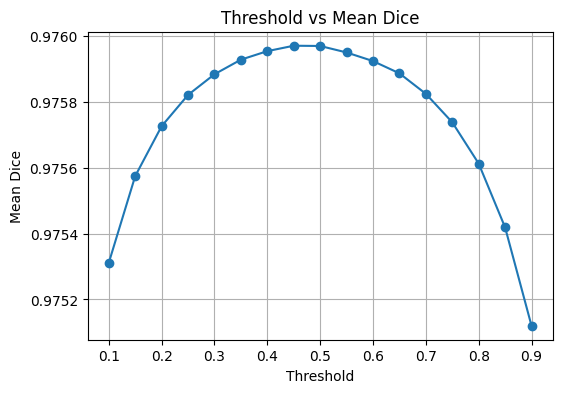

In [9]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, dice_mean_results.values(), marker='o')
plt.xlabel("Threshold")
plt.ylabel("Mean Dice")
plt.title("Threshold vs Mean Dice")
plt.grid(True)
plt.show()

In [11]:
thresholds_list = sorted(dice_per_class_results.keys())
n_classes = len(dice_per_class_results[thresholds_list[0]])

dice_tensor = torch.tensor([dice_per_class_results[thr] for thr in thresholds_list]) 

best_thr_per_class = {}

for c in range(n_classes):
    best_idx = torch.argmax(dice_tensor[:, c])
    best_thr = thresholds_list[best_idx]
    best_dice = dice_tensor[best_idx, c].item()
    
    best_thr_per_class[IND2CLASS[c]] = {
        "best_thr": best_thr,
        "best_dice": best_dice
    }

for class_name in best_thr_per_class:
    print(
        f"class: {class_name} | best threshold: {best_thr_per_class[class_name]['best_thr']:.3f}, "
        f"best dice: {best_thr_per_class[class_name]['best_dice']}"
    )

mean_dice = np.mean([v['best_dice'] for v in best_thr_per_class.values()])
print(f"Validation Dice: {mean_dice}")

class: finger-1 | best threshold: 0.350, best dice: 0.9712139368057251
class: finger-2 | best threshold: 0.450, best dice: 0.984673023223877
class: finger-3 | best threshold: 0.500, best dice: 0.9883955121040344
class: finger-4 | best threshold: 0.500, best dice: 0.9789977073669434
class: finger-5 | best threshold: 0.600, best dice: 0.9787449240684509
class: finger-6 | best threshold: 0.250, best dice: 0.988482654094696
class: finger-7 | best threshold: 0.550, best dice: 0.9867984652519226
class: finger-8 | best threshold: 0.450, best dice: 0.9804475903511047
class: finger-9 | best threshold: 0.500, best dice: 0.9823324084281921
class: finger-10 | best threshold: 0.350, best dice: 0.9895024299621582
class: finger-11 | best threshold: 0.450, best dice: 0.9811622500419617
class: finger-12 | best threshold: 0.650, best dice: 0.9804149866104126
class: finger-13 | best threshold: 0.650, best dice: 0.9812875986099243
class: finger-14 | best threshold: 0.550, best dice: 0.9883334040641785
cla

In [12]:
class XRayInferenceDataset(Dataset):
    def __init__(self, cfg):
        self.image_root = TEST_ROOT
        
        pngs = {
            os.path.relpath(os.path.join(root, fname), start=self.image_root)
            for root, _dirs, files in os.walk(self.image_root)
            for fname in files
            if os.path.splitext(fname)[1].lower() == ".png"
        }
        
        _filenames = pngs
        _filenames = np.array(sorted(_filenames))
        
        self.filenames = _filenames
        self.transforms = get_test_transform(cfg.img_size)
        self.tta_transforms = get_tta_transform() if cfg.tta else None
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, item):
        image_name = self.filenames[item]
        image_path = os.path.join(self.image_root, image_name)
        
        image = cv2.imread(image_path)
        image = image / 255.
        
        if self.transforms is not None:
            inputs = {"image": image}
            result = self.transforms(**inputs)
            image = result["image"]
        
        if self.tta_transforms is not None:
            tta_result = self.tta_transforms(image=image)
            tta_image = tta_result["image"]

            image = np.stack([image, tta_image], axis=0)

        if self.tta_transforms is None:
            image = image.transpose(2, 0, 1)
        else:
            image = image.transpose(0, 3, 1, 2)
        
        image = torch.from_numpy(image).float()
            
        return image, image_name

In [14]:
def test(model, data_loader, class_thr, tta=False):
    model = model.cuda()
    model.eval()

    rles = []
    filename_and_class = []
    with torch.no_grad():
        for step, (images, image_names) in tqdm(enumerate(data_loader), total=len(data_loader)):
            images = images.cuda()
            
            if not tta: 
                outputs = model(images)
            else:
                if images.dim() == 4 and images.size(0) % 2 == 0:  # TTA 2개 가정
                    batch_size = images.size(0) // 2
                    images = images.view(batch_size, 2, images.size(1), images.size(2), images.size(3))

                batch_size, n_tta, C, H, W = images.shape            
                outputs_tta = []
                
                for t in range(n_tta):
                    img = images[:, t]
                    output = model(img)
                    outputs_tta.append(output)

                outputs = torch.stack(outputs_tta, dim=1)
                outputs[:, 1] = torch.flip(outputs[:, 1], dims=[-1])
                outputs = torch.mean(outputs, dim=1)
            
            outputs = F.interpolate(outputs, size=(2048, 2048), mode="bilinear")
            outputs = torch.sigmoid(outputs)
            
            class_thr = class_thr.to(outputs.device)
            
            outputs = (outputs > class_thr).detach().cpu().numpy()
            
            for output, image_name in zip(outputs, image_names):
                for c, segm in enumerate(output):
                    rle = encode_mask_to_rle(segm)
                    rles.append(rle)
                    filename_and_class.append(f"{IND2CLASS[c]}_{image_name}")
                    
    return rles, filename_and_class

In [18]:
model = torch.load(os.path.join(cfg.saved_root, cfg.saved_name), weights_only=False)

test_dataset = XRayInferenceDataset(cfg)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers_val,
    drop_last=False
)

class_thr = [
    best_thr_per_class[IND2CLASS[c]]['best_thr']
    for c in range(len(IND2CLASS))
]

class_thr = torch.tensor(class_thr).view(1, -1, 1, 1)
    
rles, filename_and_class = test(model, test_loader, class_thr, tta=cfg.tta)
    
classes, filename = zip(*[x.split("_") for x in filename_and_class])
image_name = [os.path.basename(f) for f in filename]
df = pd.DataFrame({
    "image_name": image_name,
    "class": classes,
    "rle": rles,
})
df.to_csv("/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/outputs/output_threshold.csv", index=False)

  0%|          | 0/144 [00:00<?, ?it/s]

In [ ]:
image = cv2.imread(os.path.join(TEST_ROOT, filename_and_class[0].split("_")[1]))

preds = []
for rle in rles[:len(CLASSES)]:
    pred = decode_rle_to_mask(rle, height=2048, width=2048)
    preds.append(pred)

preds = np.stack(preds, 0)

def label2rgb(label):
    image_size = label.shape[1:] + (3, )
    image = np.zeros(image_size, dtype=np.uint8)
    
    for i, class_label in enumerate(label):
        image[class_label == 1] = PALETTE[i]
        
    return image

fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(image)    # remove channel dimension
ax[1].imshow(label2rgb(preds))

plt.show()
